In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
!pip install datasets pandas matplotlib scikit-learn nltk wordcloud


In [ ]:
dataset = load_dataset("rbnuria/SentiMP-En")

README.md:   0%|          | 0.00/2.99k [00:00<?, ?B/s]

en.csv:   0%|          | 0.00/110k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/480 [00:00<?, ? examples/s]

In [ ]:
df = dataset["train"].to_pandas()

In [ ]:
df.head(10)

,full_text,fold,label_1,label_2,label_3,majority_vote,tie_break,gold_label
0,Britain’s future cannot be as tax haven attemp...,3,1,1,1,1,NaN,1
1,📻LISTEN: The Indian variant is a serious conce...,3,-1,-1,-1,-1,NaN,-1
2,Still in the mix #SCO @ScotlandNT - positive p...,0,1,1,1,1,NaN,1
3,🇬🇧Great to see that the #EveryoneIn scheme has...,3,1,1,1,1,NaN,1
4,In the years I’ve been campaigning on menopaus...,3,1,1,0,1,NaN,1
5,Proud to be one of the hundreds of thousands o...,1,1,1,1,1,NaN,1
6,The UK welcomes the preliminary assessment of ...,4,1,1,1,1,NaN,1
7,On the #claddingscandal @LibDems are clear: le...,0,-1,-1,0,-1,NaN,-1
8,Good find 🤖 https://t.co/5XfLUxtoXt,3,1,1,1,1,NaN,1
9,Football is the people's game and should be fo...,3,-1,-1,0,-1,NaN,-1


In [ ]:
df.describe()

,fold,label_1,label_2,label_3,tie_break,gold_label
count,480.000000,480.000000,480.000000,480.000000,9.000000,480.000000
mean,1.970833,0.231250,0.254167,0.258333,-0.444444,0.231250
std,1.407994,0.844151,0.870524,0.822399,0.726483,0.858862
min,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,1.000000,-1.000000,-1.000000,0.000000,-1.000000,-1.000000
50%,2.000000,0.000000,1.000000,0.500000,-1.000000,1.000000
75%,3.000000,1.000000,1.000000,1.000000,0.000000,1.000000
max,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   full_text      480 non-null    object 
 1   fold           480 non-null    int64  
 2   label_1        480 non-null    int64  
 3   label_2        480 non-null    int64  
 4   label_3        480 non-null    int64  
 5   majority_vote  480 non-null    object 
 6   tie_break      9 non-null      float64
 7   gold_label     480 non-null    int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 30.1+ KB


In [ ]:
df.isnull().sum()

,0
full_text,0
fold,0
label_1,0
label_2,0
label_3,0
majority_vote,0
tie_break,471
gold_label,0


In [ ]:
df["tie_break"]=df["tie_break"].fillna(df["tie_break"].mode()[0],inplace=True)

/tmp/ipykernel_897/79240379.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["tie_break"]=df["tie_break"].fillna(df["tie_break"].mode()[0],inplace=True)


In [ ]:
df.isnull().sum()

,0
full_text,0
fold,0
label_1,0
label_2,0
label_3,0
majority_vote,0
tie_break,480
gold_label,0


In [ ]:
df["tie_break"].mode()

,tie_break


In [ ]:
df["tie_break"].value_counts(dropna=False)

,count
tie_break,
None,480


In [ ]:
df["tie_break"].head(10)

,tie_break
0,None
1,None
2,None
3,None
4,None
5,None
6,None
7,None
8,None
9,None


In [ ]:
df["tie_break"].count()

np.int64(0)

In [ ]:
df["tie_break"]=df["tie_break"].fillna("unknown")

In [ ]:
df.isnull().sum()

,0
full_text,0
fold,0
label_1,0
label_2,0
label_3,0
majority_vote,0
tie_break,0
gold_label,0


## 2. Data Preparation

The `tie_break` variable is not required for the sentiment classification model. The analysis will use `full_text` as the input feature and `gold_label` as the target sentiment label.


In [ ]:
# Correct matplotlib import and prepare the modelling dataframe
import matplotlib.pyplot as plt
import numpy as np
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Keep only the variables required for the sentiment model
analysis_df = df[['full_text', 'gold_label']].copy()

# Check duplicates
print("Duplicate rows:", analysis_df.duplicated().sum())

# Remove duplicate text-label rows, if any
analysis_df = analysis_df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", analysis_df.shape)
analysis_df.head()


Duplicate rows: 0
Shape after removing duplicates: (480, 2)


,full_text,gold_label
0,Britain’s future cannot be as tax haven attemp...,1
1,📻LISTEN: The Indian variant is a serious conce...,-1
2,Still in the mix #SCO @ScotlandNT - positive p...,1
3,🇬🇧Great to see that the #EveryoneIn scheme has...,1
4,In the years I’ve been campaigning on menopaus...,1


## 3. Sentiment Label Mapping

The gold-standard labels are converted into readable sentiment categories:

- **-1 = Negative**
- **0 = Neutral**
- **1 = Positive**


In [ ]:
label_map = {
    -1: 'Negative',
     0: 'Neutral',
     1: 'Positive'
}

analysis_df['sentiment'] = analysis_df['gold_label'].map(label_map)

analysis_df[['full_text', 'gold_label', 'sentiment']].head(10)


,full_text,gold_label,sentiment
0,Britain’s future cannot be as tax haven attemp...,1,Positive
1,📻LISTEN: The Indian variant is a serious conce...,-1,Negative
2,Still in the mix #SCO @ScotlandNT - positive p...,1,Positive
3,🇬🇧Great to see that the #EveryoneIn scheme has...,1,Positive
4,In the years I’ve been campaigning on menopaus...,1,Positive
5,Proud to be one of the hundreds of thousands o...,1,Positive
6,The UK welcomes the preliminary assessment of ...,1,Positive
7,On the #claddingscandal @LibDems are clear: le...,-1,Negative
8,Good find 🤖 https://t.co/5XfLUxtoXt,1,Positive
9,Football is the people's game and should be fo...,-1,Negative


In [ ]:
# Sentiment frequency and percentage distribution
sentiment_counts = analysis_df['sentiment'].value_counts()
sentiment_percent = analysis_df['sentiment'].value_counts(normalize=True).mul(100).round(2)

sentiment_summary = pd.DataFrame({
    'Frequency': sentiment_counts,
    'Percentage': sentiment_percent
})

sentiment_summary


,Frequency,Percentage
sentiment,,
Positive,245,51.04
Negative,134,27.92
Neutral,101,21.04


## 4. Exploratory Data Analysis


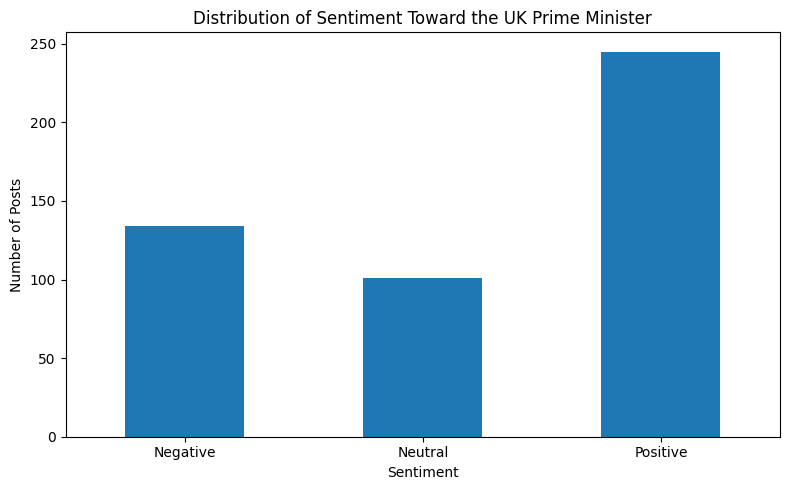

In [ ]:
# Bar chart of sentiment distribution
order = ['Negative', 'Neutral', 'Positive']
counts = analysis_df['sentiment'].value_counts().reindex(order, fill_value=0)

plt.figure(figsize=(8, 5))
counts.plot(kind='bar')
plt.title('Distribution of Sentiment Toward the UK Prime Minister')
plt.xlabel('Sentiment')
plt.ylabel('Number of Posts')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# Text-length analysis
analysis_df['character_count'] = analysis_df['full_text'].astype(str).str.len()
analysis_df['word_count'] = analysis_df['full_text'].astype(str).str.split().str.len()

analysis_df[['character_count', 'word_count']].describe()


,character_count,word_count
count,480.000000,480.000000
mean,207.581250,31.527083
std,81.806953,13.705191
min,22.000000,1.000000
25%,143.000000,21.000000
50%,231.000000,35.000000
75%,277.000000,43.000000
max,334.000000,54.000000


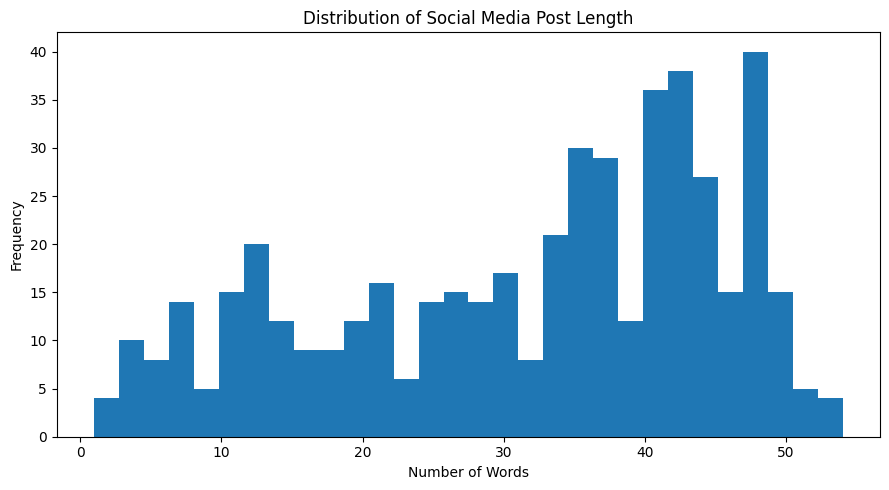

In [ ]:
plt.figure(figsize=(9, 5))
plt.hist(analysis_df['word_count'], bins=30)
plt.title('Distribution of Social Media Post Length')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


## 5. Text Preprocessing

URLs, mentions, punctuation, numbers and unnecessary whitespace are removed. Stop words are removed while retaining important negation terms such as **not**, **no**, and **nor**, because they can change sentiment meaning.


In [ ]:
# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))

# Keep negation words because they are important in sentiment analysis
for word in ['no', 'nor', 'not']:
    stop_words.discard(word)

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\.\S+', ' ', text)

    # Remove user mentions
    text = re.sub(r'@\w+', ' ', text)

    # Keep hashtag words but remove the # symbol
    text = re.sub(r'#(\w+)', r'\1', text)

    # Remove HTML entities
    text = re.sub(r'&\w+;', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Remove punctuation and non-alphabetic characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize, remove stop words, and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in text.split()
        if word not in stop_words and len(word) > 2
    ]

    return ' '.join(words)

analysis_df['clean_text'] = analysis_df['full_text'].apply(clean_text)

# Remove rows that become empty after cleaning
analysis_df = analysis_df[analysis_df['clean_text'].str.strip() != ''].reset_index(drop=True)

analysis_df[['full_text', 'clean_text', 'sentiment']].head(10)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


,full_text,clean_text,sentiment
0,Britain’s future cannot be as tax haven attemp...,britain future cannot tax attempting undercut ...,Positive
1,📻LISTEN: The Indian variant is a serious conce...,listen indian variant serious concern happens ...,Negative
2,Still in the mix #SCO @ScotlandNT - positive p...,still mix sco positive performance tonight cou...,Positive
3,🇬🇧Great to see that the #EveryoneIn scheme has...,great see everyonein scheme impact must contin...,Positive
4,In the years I’ve been campaigning on menopaus...,year campaigning menopause first time high pro...,Positive
5,Proud to be one of the hundreds of thousands o...,proud one hundred thousand people getting vacc...,Positive
6,The UK welcomes the preliminary assessment of ...,welcome preliminary assessment mission fundame...,Positive
7,On the #claddingscandal @LibDems are clear: le...,claddingscandal clear leaseholder not pay penn...,Negative
8,Good find 🤖 https://t.co/5XfLUxtoXt,good find,Positive
9,Football is the people's game and should be fo...,football people game people not uefa bigwig ti...,Negative


## 6. Word Clouds


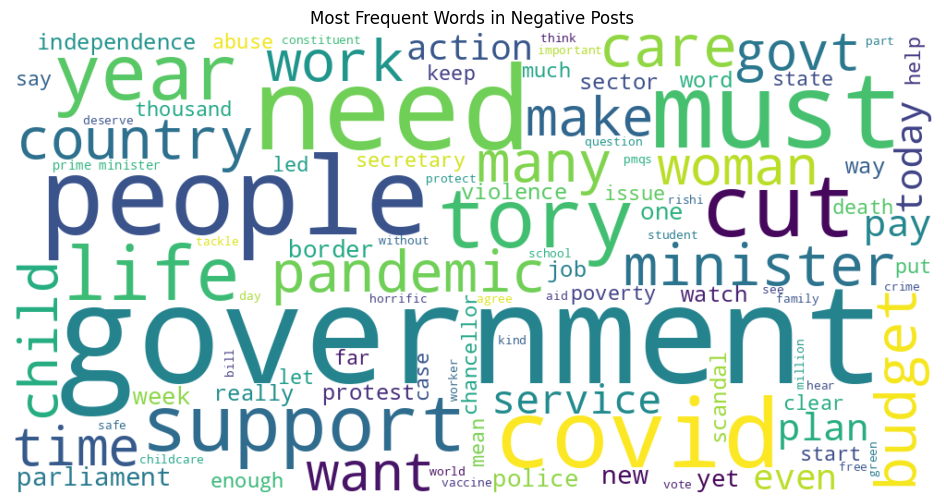

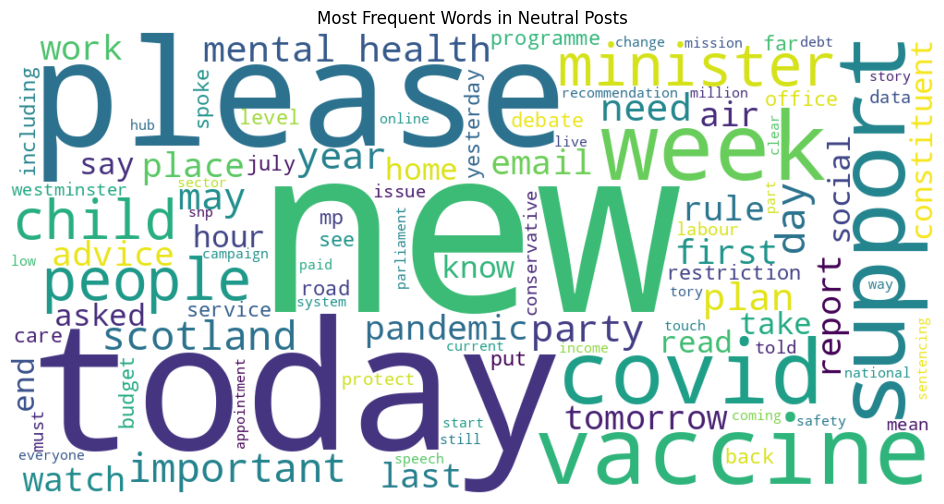

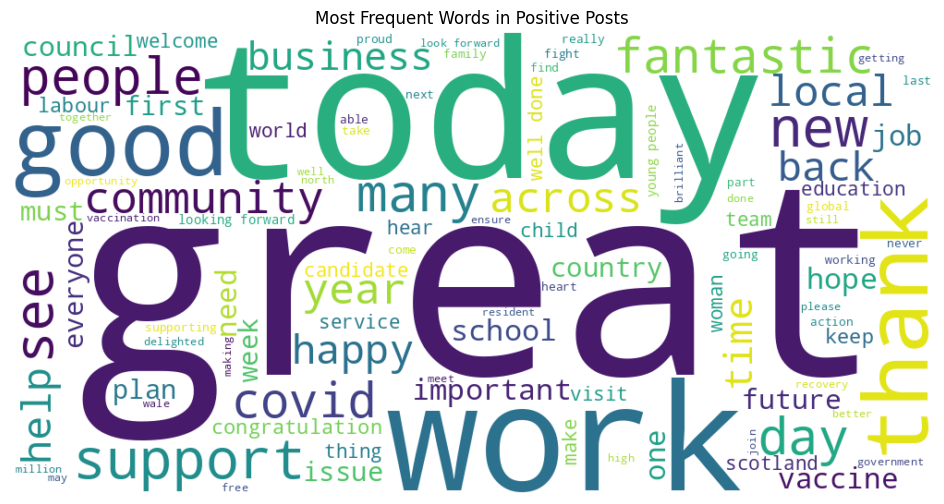

In [ ]:
from wordcloud import WordCloud

def show_wordcloud(sentiment):
    text = ' '.join(
        analysis_df.loc[
            analysis_df['sentiment'] == sentiment,
            'clean_text'
        ]
    )

    if not text.strip():
        print(f'No text available for {sentiment}')
        return

    wc = WordCloud(
        width=1000,
        height=500,
        background_color='white',
        max_words=100
    ).generate(text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Most Frequent Words in {sentiment} Posts')
    plt.show()

for sentiment in ['Negative', 'Neutral', 'Positive']:
    show_wordcloud(sentiment)


## 7. Train-Test Split and TF-IDF Feature Extraction


In [ ]:
from sklearn.model_selection import train_test_split

X = analysis_df['clean_text']
y = analysis_df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))
print("\nTraining class distribution:")
print(y_train.value_counts())


Training observations: 383
Testing observations: 96

Training class distribution:
sentiment
Positive    195
Negative    107
Neutral      81
Name: count, dtype: int64


## 8. Machine Learning Model Development

Four supervised machine-learning classifiers are compared:

1. Logistic Regression
2. Multinomial Naive Bayes
3. Linear Support Vector Machine
4. Random Forest


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

models = {
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=10000,
            sublinear_tf=True
        )),
        ('classifier', LogisticRegression(
            max_iter=2000,
            class_weight='balanced',
            random_state=42
        ))
    ]),

    'Multinomial Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=10000,
            sublinear_tf=True
        )),
        ('classifier', MultinomialNB())
    ]),

    'Linear SVM': Pipeline([
        ('tfidf', TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=10000,
            sublinear_tf=True
        )),
        ('classifier', LinearSVC(
            class_weight='balanced',
            random_state=42
        ))
    ]),

    'Random Forest': Pipeline([
        ('tfidf', TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=10000
        )),
        ('classifier', RandomForestClassifier(
            n_estimators=300,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ])
}

print("Models created successfully.")


Models created successfully.


## 9. Model Training and Evaluation


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

results = []
predictions_by_model = {}
trained_models = {}

for model_name, model in models.items():

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    trained_models[model_name] = model
    predictions_by_model[model_name] = y_pred

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test, y_pred, average='weighted', zero_division=0
    )
    recall = recall_score(
        y_test, y_pred, average='weighted', zero_division=0
    )
    f1 = f1_score(
        y_test, y_pred, average='weighted', zero_division=0
    )

    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        labels=['Negative', 'Neutral', 'Positive'],
        zero_division=0
    ))



Logistic Regression
Accuracy : 0.7188
Precision: 0.7082
Recall   : 0.7188
F1 Score : 0.7027

Classification Report:
              precision    recall  f1-score   support

    Negative       0.62      0.67      0.64        27
     Neutral       0.64      0.35      0.45        20
    Positive       0.79      0.90      0.84        49

    accuracy                           0.72        96
   macro avg       0.68      0.64      0.64        96
weighted avg       0.71      0.72      0.70        96


Multinomial Naive Bayes
Accuracy : 0.5208
Precision: 0.5445
Recall   : 0.5208
F1 Score : 0.3675

Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      0.04      0.07        27
     Neutral       0.00      0.00      0.00        20
    Positive       0.52      1.00      0.68        49

    accuracy                           0.52        96
   macro avg       0.51      0.35      0.25        96
weighted avg       0.54      0.52      0.37        96



In [ ]:
# Compare all models
results_df = pd.DataFrame(results).sort_values(
    'F1 Score',
    ascending=False
).reset_index(drop=True)

results_df.round(4)


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7188,0.7082,0.7188,0.7027
1,Linear SVM,0.6667,0.6554,0.6667,0.6377
2,Random Forest,0.5521,0.5146,0.5521,0.4743
3,Multinomial Naive Bayes,0.5208,0.5445,0.5208,0.3675


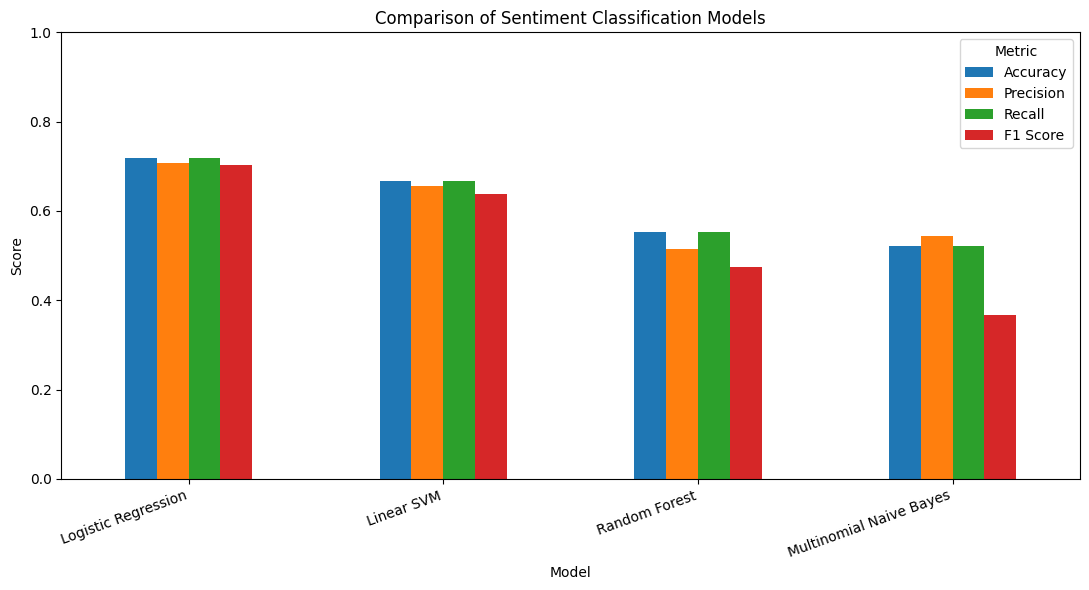

In [ ]:
# Visual comparison of model performance
metric_columns = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

results_df.set_index('Model')[metric_columns].plot(
    kind='bar',
    figsize=(11, 6)
)

plt.title('Comparison of Sentiment Classification Models')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()


## 10. Best Model and Confusion Matrix


In [ ]:
best_model_name = results_df.loc[0, 'Model']
best_model = trained_models[best_model_name]
best_predictions = predictions_by_model[best_model_name]

print("Best model:", best_model_name)
print("Weighted F1 Score:", round(results_df.loc[0, 'F1 Score'], 4))


Best model: Logistic Regression
Weighted F1 Score: 0.7027


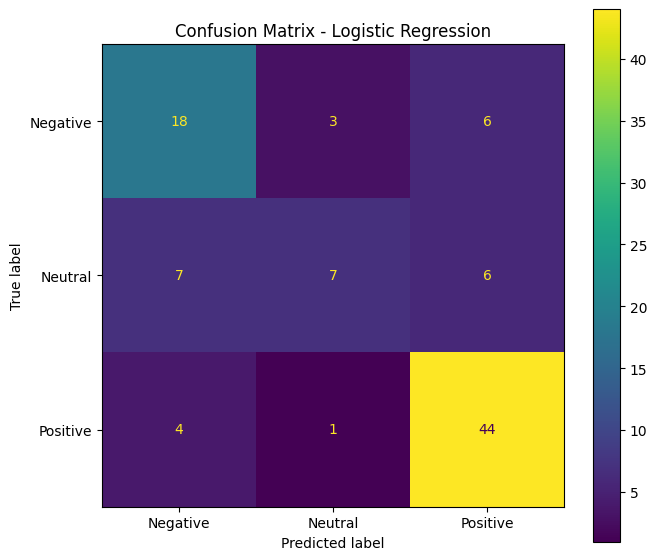

In [ ]:
cm = confusion_matrix(
    y_test,
    best_predictions,
    labels=['Negative', 'Neutral', 'Positive']
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Neutral', 'Positive']
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format='d')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()


## 11. Five-Fold Cross-Validation

Because the dataset is relatively small, cross-validation provides a more stable estimate of model performance than relying only on a single train-test split.


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for model_name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring='f1_weighted'
    )

    cv_results.append({
        'Model': model_name,
        'Mean CV F1': scores.mean(),
        'Std CV F1': scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(
    'Mean CV F1',
    ascending=False
).reset_index(drop=True)

cv_results_df.round(4)


,Model,Mean CV F1,Std CV F1
0,Logistic Regression,0.6676,0.0501
1,Linear SVM,0.6417,0.0346
2,Random Forest,0.5405,0.0221
3,Multinomial Naive Bayes,0.3821,0.0287


## 12. Overall Public Sentiment


In [ ]:
overall_summary = (
    analysis_df['sentiment']
    .value_counts()
    .reindex(['Negative', 'Neutral', 'Positive'], fill_value=0)
    .reset_index()
)

overall_summary.columns = ['Sentiment', 'Frequency']
overall_summary['Percentage'] = (
    overall_summary['Frequency'] /
    overall_summary['Frequency'].sum() * 100
).round(2)

overall_summary


,Sentiment,Frequency,Percentage
0,Negative,134,27.97
1,Neutral,101,21.09
2,Positive,244,50.94


In [ ]:
dominant_row = overall_summary.loc[
    overall_summary['Frequency'].idxmax()
]

print(
    f"The dominant sentiment in the dataset is "
    f"{dominant_row['Sentiment']} "
    f"({dominant_row['Percentage']:.2f}%)."
)


The dominant sentiment in the dataset is Positive (50.94%).


## 13. Error Analysis


In [ ]:
error_analysis = pd.DataFrame({
    'Text': X_test.values,
    'Actual Sentiment': y_test.values,
    'Predicted Sentiment': best_predictions
})

misclassified = error_analysis[
    error_analysis['Actual Sentiment'] !=
    error_analysis['Predicted Sentiment']
].copy()

print("Number of misclassified posts:", len(misclassified))
misclassified.head(20)


Number of misclassified posts: 27


,Text,Actual Sentiment,Predicted Sentiment
2,following question delighted announced support...,Positive,Neutral
5,anyone ever attended constituency labour party...,Neutral,Positive
6,govt offered generous business support package...,Positive,Negative
16,signed cross party letter prime minister askin...,Neutral,Negative
18,benefit boris seat christmas present majority ...,Negative,Positive
19,prime minister outlined one way road freedom,Neutral,Negative
20,spoke onlineabuse womeninpolitics yesterday ta...,Positive,Negative
25,start nonsense majority holyrood also think re...,Negative,Neutral
30,even though half term recess politics continue...,Neutral,Negative
31,sending latest edition newsletter soon sign see,Neutral,Positive


## 14. Predicting Sentiment of New Statements


In [ ]:
def predict_sentiment(text):
    cleaned = clean_text(text)

    if cleaned == '':
        return 'Unable to classify'

    return best_model.predict([cleaned])[0]

examples = [
    "The Prime Minister is doing an excellent job for the country.",
    "I am very disappointed with the Prime Minister's decision.",
    "The Prime Minister spoke in Parliament today."
]

for statement in examples:
    print("Statement:", statement)
    print("Predicted sentiment:", predict_sentiment(statement))
    print("-" * 60)


Statement: The Prime Minister is doing an excellent job for the country.
Predicted sentiment: Negative
------------------------------------------------------------
Statement: I am very disappointed with the Prime Minister's decision.
Predicted sentiment: Negative
------------------------------------------------------------
Statement: The Prime Minister spoke in Parliament today.
Predicted sentiment: Negative
------------------------------------------------------------


## 15. Save the Best Model


In [ ]:
import joblib

joblib.dump(best_model, 'uk_pm_sentiment_best_model.pkl')

print(
    f"{best_model_name} has been saved as "
    "'uk_pm_sentiment_best_model.pkl'"
)


Logistic Regression has been saved as 'uk_pm_sentiment_best_model.pkl'


## 16. Final Model Summary


In [ ]:
print("FINAL SENTIMENT ANALYSIS SUMMARY")
print("=" * 60)
print("Number of observations:", len(analysis_df))
print("Best hold-out model:", best_model_name)
print(
    "Hold-out weighted F1:",
    round(results_df.loc[0, 'F1 Score'], 4)
)
print("\nModel comparison:")
display(results_df.round(4))
print("\nCross-validation comparison:")
display(cv_results_df.round(4))
print("\nOverall sentiment distribution:")
display(overall_summary)


FINAL SENTIMENT ANALYSIS SUMMARY
Number of observations: 479
Best hold-out model: Logistic Regression
Hold-out weighted F1: 0.7027

Model comparison:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.7188,0.7082,0.7188,0.7027
1,Linear SVM,0.6667,0.6554,0.6667,0.6377
2,Random Forest,0.5521,0.5146,0.5521,0.4743
3,Multinomial Naive Bayes,0.5208,0.5445,0.5208,0.3675



Cross-validation comparison:


,Model,Mean CV F1,Std CV F1
0,Logistic Regression,0.6676,0.0501
1,Linear SVM,0.6417,0.0346
2,Random Forest,0.5405,0.0221
3,Multinomial Naive Bayes,0.3821,0.0287



Overall sentiment distribution:


,Sentiment,Frequency,Percentage
0,Negative,134,27.97
1,Neutral,101,21.09
2,Positive,244,50.94
